In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Leap Frog and Euler Functions

In [2]:
# Define LeapFrog function
# Takes an initial x and y position, initial x and y velocity, time step, and final time. Uses Leap Frog integration
# to calculate a circular orbit using classical orbital mechanics. Loops over the given time step until the final time
# and calculates position, velocity, and acceleration at each step.
# Returns x array, y array, x velocity array, y velocity array, and time array
def leapfrog(xi, yi, vxi, vyi, dt, time):
    # Constants
    G = 4 * np.pi**2
    M = 1.0
    # Initial Arrays with loaded Initial Vals
    x_arr = np.array([xi])
    y_arr = np.array([yi])
    velx_arr = np.array([vxi])
    vely_arr = np.array([vyi])
    time_arr = np.arange(0, time, dt)

    # Calculate orbital position, velocity, and acceleration over time
    for i in range(len(time_arr)):
        # Calculate current distance and acceleration
        r = np.sqrt(x_arr[i]**2 + y_arr[i]**2)
        ax = -G * M * x_arr[i] / (r**3)
        ay = -G * M * y_arr[i] / (r**3)
        
        # Update velocity by a half-step (Kick)
        vx_half = velx_arr[i] + ax * (dt / 2.0)
        vy_half = vely_arr[i] + ay * (dt / 2.0)
        
        # Update position by a full step using the half-step velocity (Drift)
        x_new = x_arr[i] + vx_half * dt
        x_arr = np.append(x_arr, x_new)
        y_new = y_arr[i] + vy_half * dt
        y_arr = np.append(y_arr, y_new)
        
        # Calculate new position and acceleration
        r_new = np.sqrt(x_arr[i + 1]**2 + y_arr[i + 1]**2)
        ax_new = -G * M * x_arr[i + 1] / (r_new**3)
        ay_new = -G * M * y_arr[i + 1] / (r_new**3)
        
        # Update velocity by another half-step (Kick to finish)
        new_vx = vx_half + ax_new * (dt / 2.0)
        velx_arr = np.append(velx_arr, new_vx)
        new_vy = vy_half + ay_new * (dt / 2.0)
        vely_arr = np.append(vely_arr, new_vy)

    return x_arr, y_arr, velx_arr, vely_arr, time_arr

In [ ]:
# Define Euler function
# Takes an initial x and y position, initial x and y velocity, time step, and final time. Uses Euler method integration
# to calculate a circular orbit using classical orbital mechanics. Loops over the given time step until the final time
# and calculates position, velocity, and acceleration at each step.
# Returns x array, y array, x velocity array, y velocity array, and time array
def euler(xi, yi, vxi, vyi, dt, time):
    # Constants
    G = 4 * np.pi**2
    M = 1.0
    # Initial Arrays with loaded Initial Vals
    x_arr = np.array([xi])
    y_arr = np.array([yi])
    velx_arr = np.array([vxi])
    vely_arr = np.array([vyi])
    time_arr = np.arange(0, time, dt)

    # Calculate orbital position, velocity, and acceleration over time
    for i in range(len(time_arr)):
        # Calculate current distance and acceleration
        r = np.sqrt(x_arr[i]**2 + y_arr[i]**2)
        ax = -G * M * x_arr[i] / (r**3)
        ay = -G * M * y_arr[i] / (r**3)
        
        # Update position with current velocity
        x_new = x_arr[i] + velx_arr[i] * dt
        x_arr = np.append(x_arr, x_new)
        y_new = y_arr[i] + vely_arr[i] * dt
        y_arr = np.append(y_arr, y_new)
        
        # Update velocity with current acceleration
        vx_new = velx_arr[i] + ax * dt
        velx_arr = np.append(velx_arr, vx_new)
        vy_new = vely_arr[i] + ay * dt
        vely_arr = np.append(vely_arr, vy_new)

    return x_arr, y_arr, velx_arr, vely_arr, time_arr

# 1. Earth and Sun

A.) Initialize Earth at a distance r0 = 1 AU with a velocity given by circular motion.
Integrate the motion for at least 3 orbital periods using both Euler and Leapfrog method.

In [ ]:
# Initial Values
G = 4 * np.pi**2
M = 1.0
x_initial = 1.0 # AU
y_initial = 0.0
vx_initial = 0.0 # AU/yr
vy_initial = np.sqrt(G * M / (x_initial**2 + y_initial**2))
time = 3 # Years
dt = 0.003 # Orbit time step

In [63]:
leap_x, leap_y, leap_velx, leap_vely, leap_time = leapfrog(x_initial, y_initial, vx_initial, vy_initial, dt, time)
eul_x, eul_y, eul_velx, eul_vely, eul_time = euler(x_initial, y_initial, vx_initial, vy_initial, dt, time)

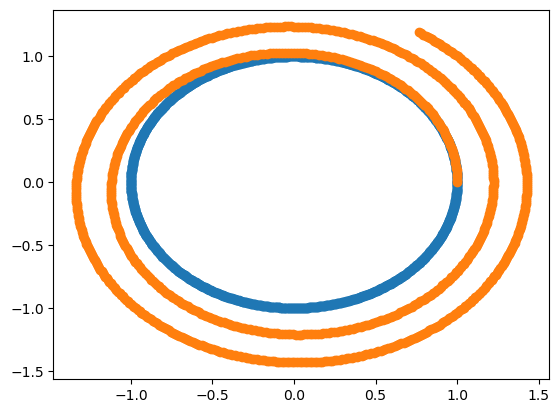

In [64]:
# Check shape of points and scale (should be within 2 x 2)
plt.scatter(leap_x, leap_y)
plt.scatter(eul_x, eul_y)

In [74]:
# Plot smooth orbit movie
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('x Position (AU)')
ax.set_ylabel('y Position (AU)')
ax.set_title('Earth Orbit (Euler and Leap Frog)')

# Plot the Earth, its orbital trail, and the Sun
earth_leap, = ax.plot([], [], 'bo', markersize = 6, label = 'Leap Frog') # Leap Frog
earth_euler, = ax.plot([], [], 'ro', markersize = 6, label = 'Euler') # Euler
trail_leap, = ax.plot([], [], 'b-', alpha = 0.5)
trail_euler, = ax.plot([], [], 'r-', alpha = 0.5)
ax.plot(0, 0, 'yo', markersize = 12, label = 'Sun')
ax.legend()

# Define functions for the animation to update each frame
# =======================================================
# Define the Initialization function
def init():
    earth_leap.set_data([], [])
    earth_euler.set_data([], [])
    trail_leap.set_data([], [])
    trail_euler.set_data([], [])
    return earth_leap, earth_euler, trail_leap, trail_euler

# Define Update function
frame_step = 10 
def update(frame):
    # Step index for the frame
    idx = frame * frame_step
    
    # Update Earth position
    earth_leap.set_data([leap_x[idx]], [leap_y[idx]])
    earth_euler.set_data([eul_x[idx]], [eul_y[idx]])
    # Update trail
    trail_leap.set_data(leap_x[:idx], leap_y[:idx])
    trail_euler.set_data(eul_x[:idx], eul_y[:idx]) 
    
    return earth_leap, earth_euler, trail_leap, trail_euler
# =======================================================

# Create animation
total_frames = len(leap_x) // frame_step
ani = FuncAnimation(fig, update, frames = total_frames, init_func = init, blit = True, interval = 20)

# Display in Jupyter Notebook
plt.close() 
HTML(ani.to_jshtml())

In [75]:
# Save as a GIF
ani.save('leapfrog_orbit.gif', writer='pillow', fps=15)

Plot the speed of the Earth as a function of time. Does the speed remain constant?

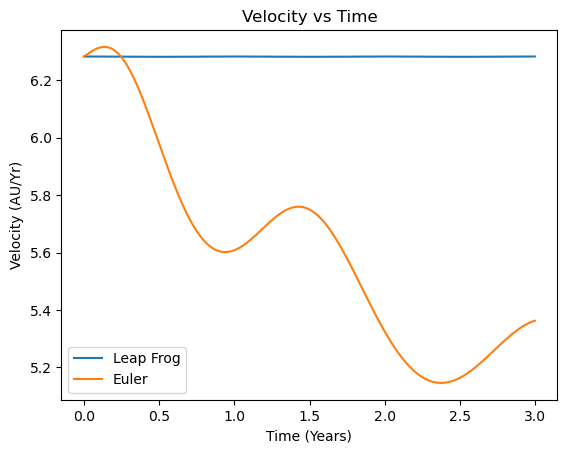

In [76]:
leap_velocity = np.sqrt(leap_velx[0:-1]**2 + leap_vely[0:-1]**2)
euler_velocity = np.sqrt(eul_velx[0:-1]**2 + eul_vely[0:-1]**2)
plt.plot(leap_time, leap_velocity, label = "Leap Frog")
plt.plot(eul_time, euler_velocity, label = "Euler")
plt.title("Velocity vs Time")
plt.xlabel("Time (Years)")
plt.ylabel("Velocity (AU/Yr)")
plt.legend()

 Compute the total specific energy, ϵ, and plot over time

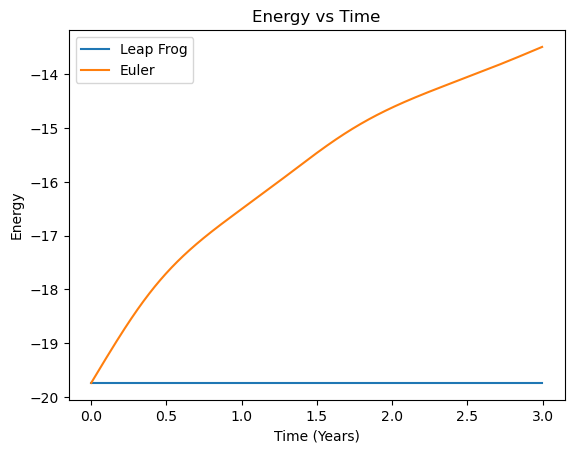

In [77]:
leap_r = np.sqrt(leap_x[0:-1]**2 + leap_y[0:-1]**2)
euler_r = np.sqrt(eul_x[0:-1]**2 + eul_y[0:-1]**2)

leap_energy = (leap_velocity**2 / 2) - (G * M / leap_r)
euler_energy = (euler_velocity**2 / 2) - (G * M / euler_r)

plt.plot(leap_time, leap_energy, label = "Leap Frog")
plt.plot(eul_time, euler_energy, label = "Euler")
plt.title("Energy vs Time")
plt.xlabel("Time (Years)")
plt.ylabel("Energy")
plt.legend()

# 2. Lower Initial Speed ($v_o = 0.8$)

In [80]:
velocity_scale = 0.8 # Percentage of the base velocity
time = 5 # Years
dt = 0.003 # Orbit time step

leap_x, leap_y, leap_velx, leap_vely, leap_time = leapfrog(x_initial, y_initial, 
                                                           vx_initial * velocity_scale, vy_initial * velocity_scale, 
                                                           dt, time)
eul_x, eul_y, eul_velx, eul_vely, eul_time = euler(x_initial, y_initial, 
                                                   vx_initial * velocity_scale, vy_initial * velocity_scale, 
                                                   dt, time)

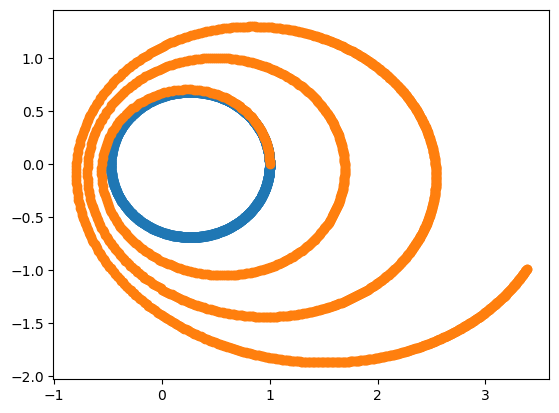

In [81]:
# Check shape of points and scale (should be within 2 x 2)
plt.scatter(leap_x, leap_y)
plt.scatter(eul_x, eul_y)

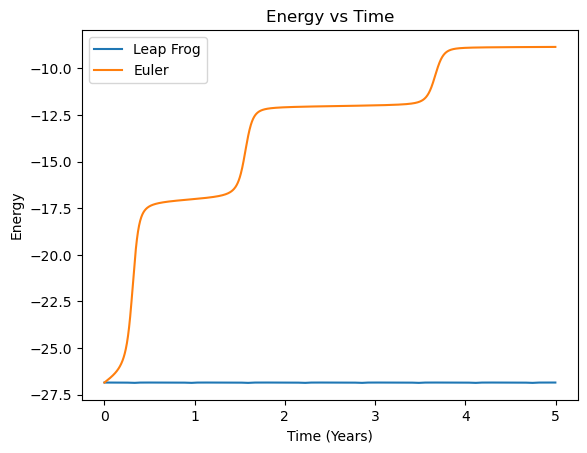

In [84]:
leap_velocity = np.sqrt(leap_velx[0:-1]**2 + leap_vely[0:-1]**2)
euler_velocity = np.sqrt(eul_velx[0:-1]**2 + eul_vely[0:-1]**2)

leap_r = np.sqrt(leap_x[0:-1]**2 + leap_y[0:-1]**2)
euler_r = np.sqrt(eul_x[0:-1]**2 + eul_y[0:-1]**2)

leap_energy = (leap_velocity**2 / 2) - (G * M / leap_r)
euler_energy = (euler_velocity**2 / 2) - (G * M / euler_r)

plt.plot(leap_time, leap_energy, label = "Leap Frog")
plt.plot(eul_time, euler_energy, label = "Euler")
plt.title("Energy vs Time")
plt.xlabel("Time (Years)")
plt.ylabel("Energy")
plt.legend()

# 3. Voyager Trajectory